# Decision Trees

Los decision trees son un método de aprendizaje supervisado **no paramétrico** (no se asume que los datos siguen una distribución particular) utilizado tanto para tareas de clasificación como de regresión.

Los decision trees donde la variable objetivo puede tomar un conjunto finito de valores se denominan **árboles de clasificación**; en estas estructuras de árbol, las hojas representan **etiquetas de clase** y las ramas representan features que llevan a esas etiquetas de clase. Los decision trees donde la variable objetivo puede tomar valores continuos (típicamente números reales) se denominan **árboles de regresión**.

**Ventajas:**
- Se pueden representar gráficamente y se interpretan fácilmente.
- Funciona con variables tanto cualitativas como cuantitativas sin necesidad de preprocesamiento.

**Desventajas:**
- La precisión no es tan buena como con otros algoritmos.
- No es robusto. Un pequeño cambio en los datos puede provocar una gran diferencia en el árbol final.

`Scikit-learn` usa el algoritmo CART (*Classification and Regression Trees*), que produce únicamente **árboles binarios** (los nodos no hoja tienen solo dos hijos). Sin embargo, otros algoritmos como ID3 pueden producir decision trees con nodos que tienen más de 2 hijos.

## Decision Trees para clasificación

`scikit-learn` proporciona la clase `DecisionTreeClassifier` para ajustar un modelo de decision tree a un dataset.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()
X = iris.data
y = iris.target


tree_clf = DecisionTreeClassifier().fit(X, y)

Existen varias herramientas que nos permiten visualizar un decision tree. Podemos observar que es uno de los modelos más interpretables que existen; simplemente en cada nodo se evalúa una condición y se sigue uno de los caminos.

In [ ]:
import dtreeviz # https://github.com/parrt/dtreeviz/blob/master/notebooks/dtreeviz_sklearn_visualisations.ipynb


viz_model = dtreeviz.model(tree_clf, X, y,
                target_name="target",
                feature_names=iris.feature_names,
                class_names=list(iris.target_names))
viz_model.view(fontname="monospace", scale=1.7)

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))  # Aumentar el tamaño de la figura
plot_tree(tree_clf,
        feature_names=iris.feature_names,
        class_names=list(iris.target_names),
        filled=True)
plt.show()

## Decision Trees para regresión

Los decision trees se pueden usar tanto para tareas de clasificación como de regresión. Estas dos categorías de problemas difieren en la naturaleza de la variable objetivo. En el caso de la clasificación, la variable objetivo es categórica, mientras que en el caso de la regresión, la variable objetivo es numérica o continua.

Aunque los decision trees para clasificación se construyen de la misma manera que los decision trees para regresión, la forma en que se hacen las predicciones es diferente. En el caso de la clasificación, la predicción se realiza asignando la clase más frecuente en el nodo terminal. **En el caso de la regresión, la predicción se realiza calculando la media de las observaciones en el training set** que pertenecen al mismo nodo terminal.

Los árboles de regresión dividen los datos de salida continuos en intervalos discretos.

Realizaremos una regresión con un decision tree sobre el mismo dataset que usamos en el notebook de linear regression.

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor

df = pd.read_csv("data/salaries.csv")

tree_reg = DecisionTreeRegressor(max_depth=3).fit(df[["YearsExperience"]], df["Salary"])

/media/DIURNOext4/alejandro/wip-clase/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names


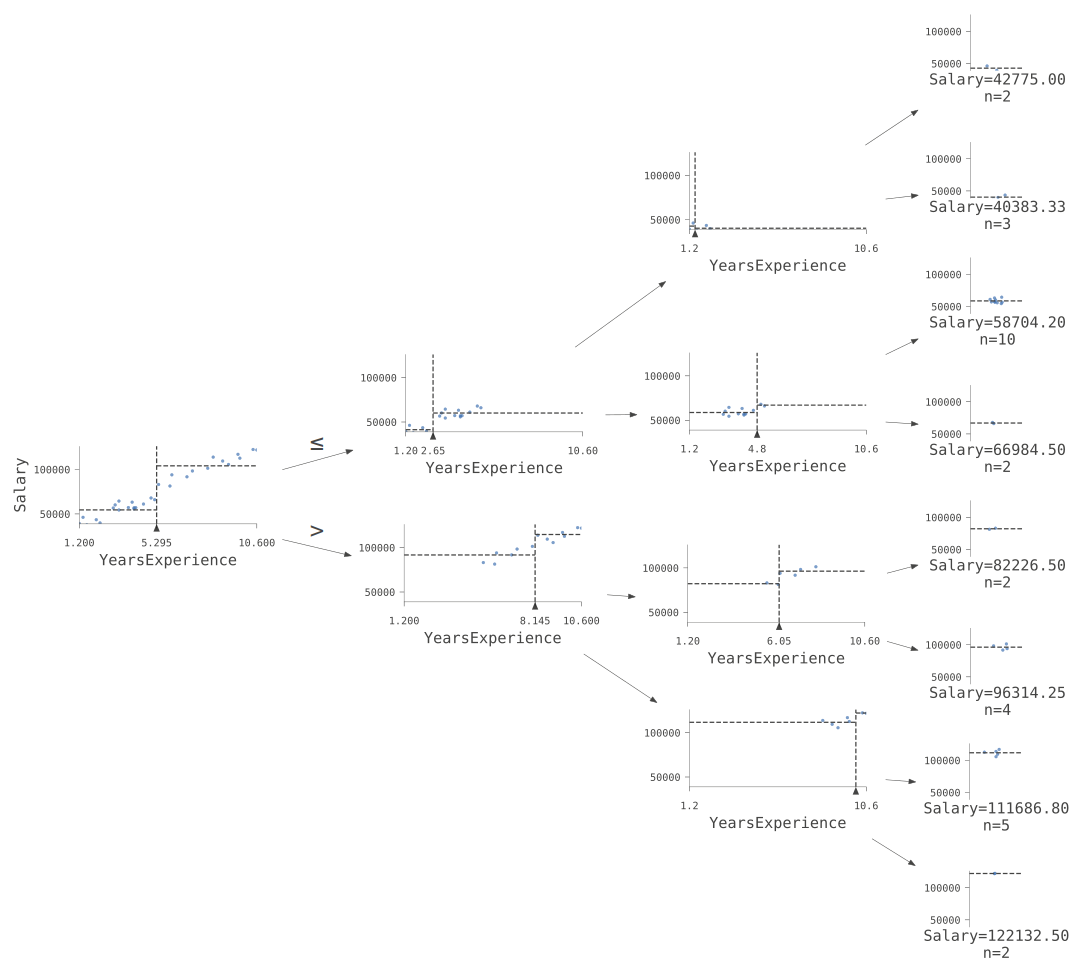

In [ ]:
viz_model = dtreeviz.model(tree_reg, df[["YearsExperience"]], df["Salary"], target_name="Salary", feature_names=["YearsExperience"])
viz_model.view(fontname="monospace", scale=1.7, orientation="LR")

In [ ]:
plt.figure(figsize=(16, 4))  # Usar matplotlib para definir el tamaño de la figura
_ = plot_tree(tree_reg, filled=True, feature_names=["YearsExperience"])

## Comparación con Linear Regression y Overfitting

Si aplicamos un árbol de regresión al mismo dataset que usamos para la linear regression, podemos observar que el árbol de regresión se ajusta mucho mejor a los datos. Esto se debe a que el árbol de regresión es capaz de capturar relaciones no lineales entre las features de entrada y la variable objetivo. El problema con esto es que tiende al **overfitting** de los datos.

In [ ]:
plt.scatter(df['YearsExperience'], df['Salary'], label='Datos reales')
df = df.sort_values(by=['YearsExperience'])
y_pred = tree_reg.predict(df[['YearsExperience']])
plt.scatter(df['YearsExperience'], y_pred, color='red', label='Predicción')
plt.plot(df['YearsExperience'], y_pred, color='red', label='Predicción', linestyle='--', alpha=0.5)
plt.xlabel('Años de Experiencia')
plt.ylabel('Salario')
plt.legend()
plt.grid(True)
plt.show()

Si creamos muchos puntos en el rango donde estamos prediciendo:

In [ ]:
import numpy as np

plt.scatter(df['YearsExperience'], df['Salary'], label='Datos reales')
x = np.linspace(0, 12, 1000)
y_pred = tree_reg.predict(x.reshape(-1, 1))
plt.plot(x, y_pred, color='red', label='Predicción')
plt.legend()
plt.grid(True)
plt.show()

Podemos observar fácilmente una de las principales desventajas de los decision trees: su tendencia al overfitting de los datos. Los decision trees tienden a tener alta varianza y, por tanto, tienden al overfitting de los datos. Esto puede mitigarse mediante la poda del árbol, limitando la profundidad del árbol, limitando el número de nodos hoja, o limitando el número mínimo de muestras necesarias para dividir un nodo interno. De hecho, hemos usado un decision tree con una profundidad máxima de solo 3. Veamos qué pasa si usamos un decision tree sin limitar su profundidad.

In [ ]:
tree_reg = DecisionTreeRegressor().fit(df[["YearsExperience"]], df["Salary"])

plt.scatter(df['YearsExperience'], df['Salary'], label='Datos reales')
x = np.linspace(0, 12, 1000)
y_pred = tree_reg.predict(x.reshape(-1, 1))
plt.plot(x, y_pred, color='red', label='Predicción')
plt.legend()
plt.grid(True)
plt.show()

El decision tree continúa haciendo divisiones hasta que cada hoja tiene una sola muestra. Este es un claro ejemplo de overfitting. Sin embargo, podemos notar que hay algunas muestras que no coinciden con su predicción (claramente entre 3 y 4, y podemos intuir otro caso poco después de 4). Esto se debe a que esas muestras tienen exactamente el mismo valor de predictor, por lo que el decision tree se ve obligado a calcular la media. Confirmemos en qué casos ocurre esto:

In [ ]:
df['YearsExperience'].value_counts().loc[lambda x: x>1]

# o de forma equivalente:
repeated_x = df['YearsExperience'].value_counts()
repeated_x.loc[repeated_x > 1]